# U-Net on Colab (AMtown01/02/03): Data Processing → Training → Testing → Evaluation

This notebook is an **end-to-end** Colab workflow for semantic segmentation with **U-Net**.

## Your requirements (what this notebook is built for)
- Runs fully in **Google Colab**.
- Uses your dataset stored in **Google Drive** (raw data stays in Drive).
- The only project code we use is the **original** U-Net repo:
  - `https://github.com/milesial/Pytorch-UNet.git`
- All pipeline logic (dataset processing, training loop, evaluation) is implemented **inside this notebook**.

## Expected Google Drive structure (default)
We assume you copied the following into Drive (under a single root folder):

### Images (raw)
- `interval5_AMtown01/interval5_CAM/*.jpg`
- `interval5_AMtown02/interval5_CAM/*.jpg`
- `interval5_AMtown03/interval5_CAM/*.jpg`

### Labels (raw) — one of these two formats
**A) ID masks (recommended)**
- `AMtown_label/interval5_AMtown01/interval5_CAM_label_id/*.png`
- `AMtown_label/interval5_AMtown02/interval5_CAM_label_id/*.png`
- `AMtown_label/interval5_AMtown03/interval5_CAM_label_id/*.png`

**B) Color masks + `cmap.py`**
- `AMtown_label/interval5_AMtown01/interval5_CAM_label_color/*.png`
- `AMtown_label/interval5_AMtown02/interval5_CAM_label_color/*.png`
- `AMtown_label/interval5_AMtown03/interval5_CAM_label_color/*.png`
- `cmap.py` (RGB → class ID mapping)

## Dataset split policy (default)
- **Train**: AMtown01 + AMtown03
- **Test**: AMtown02
- **Validation**: random split from Train

## Notes
- For reliability on Drive-mounted filesystems, DataLoader uses `num_workers=0` by default.
- You can choose between symlinking/copying prepared data for speed and storage.
- This notebook is written in **English only** as requested.

## Step 0 — Enable GPU (recommended)

Colab: `Runtime` → `Change runtime type` → `Hardware accelerator` → **GPU**.

Run this cell to confirm CUDA is available:

In [2]:
import sys
import torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    !nvidia-smi
else:
    print("No GPU detected. In Colab: Runtime → Change runtime type → GPU")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
CUDA available: True
Mon Mar 30 14:15:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                     

## Step 1 — Mount Google Drive

This gives the notebook access to your raw AMtown data stored in Drive.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 2 — Configure your dataset paths (Drive)

Set `DRIVE_DATA_ROOT` to the folder that contains:
- `interval5_AMtown01`, `interval5_AMtown02`, `interval5_AMtown03`
- `AMtown_label` (labels)
- `cmap.py`

If your Drive layout is different, just change `DRIVE_DATA_ROOT` below.

In [4]:
import zipfile
from pathlib import Path

# 压缩包所在的目录
ZIP_SOURCE_DIR = Path('/content/drive/MyDrive')
# 目标解压目录
target_dir = Path('/content/sample_data')

# 检查是否已经解压过（例如检查 interval5_AMtown01 文件夹是否存在）
if (target_dir / 'interval5_AMtown01').exists():
    print("检测到目标目录中已存在解压后的数据，跳过解压步骤。")
else:
    print("目标目录中未找到数据，开始解压...")
    target_dir.mkdir(parents=True, exist_ok=True)

    # 需要解压的 zip 文件名列表
    zip_files = [
        'Copy of interval5_AMtown01.zip',
        'Copy of interval5_AMtown02.zip',
        'Copy of interval5_AMtown03.zip',
        'Copy of interval5_CAM_label.zip'
    ]

    for zip_name in zip_files:
        zip_path = ZIP_SOURCE_DIR / zip_name
        if zip_path.exists():
            print(f'正在解压 {zip_name} ...')
            with zipfile.ZipFile(zip_path, 'r') as zf:
                zf.extractall(target_dir)
            print(f'解压完成: {zip_name}')
        else:
            print(f'未找到: {zip_path}')

目标目录中未找到数据，开始解压...
正在解压 Copy of interval5_AMtown01.zip ...
解压完成: Copy of interval5_AMtown01.zip
正在解压 Copy of interval5_AMtown02.zip ...
解压完成: Copy of interval5_AMtown02.zip
正在解压 Copy of interval5_AMtown03.zip ...
解压完成: Copy of interval5_AMtown03.zip
正在解压 Copy of interval5_CAM_label.zip ...
解压完成: Copy of interval5_CAM_label.zip


In [10]:
from pathlib import Path

# TODO: change this if your Drive folder is different
DRIVE_DATA_ROOT = Path('/content/sample_data/')
DRIVE_DATA2_ROOT = Path('/content/sample_data/')
# Labels are usually inside DRIVE_DATA_ROOT / 'AMtown_label'
DRIVE_LABEL_ROOT = DRIVE_DATA2_ROOT / 'interval5_CAM_label'

# You said you will store cmap.py in Drive
DRIVE_CMAP_PATH = DRIVE_DATA_ROOT / 'cmap.py'

print('DRIVE_DATA_ROOT :', DRIVE_DATA_ROOT)
print('DRIVE_LABEL_ROOT:', DRIVE_LABEL_ROOT)
print('DRIVE_CMAP_PATH :', DRIVE_CMAP_PATH)

assert DRIVE_DATA_ROOT.exists(), f"Not found: {DRIVE_DATA_ROOT}"
assert DRIVE_CMAP_PATH.exists(), f"Not found: {DRIVE_CMAP_PATH} (upload cmap.py to Drive)"
assert DRIVE_LABEL_ROOT.exists(), (
    f"Not found: {DRIVE_LABEL_ROOT}. You must upload AMtown labels to Drive under AMtown_label/..."
)

DRIVE_DATA_ROOT : /content/sample_data
DRIVE_LABEL_ROOT: /content/sample_data/interval5_CAM_label
DRIVE_CMAP_PATH : /content/sample_data/cmap.py


## Step 3 — Verify raw data structure (images + labels)

This step checks that:
- Each split has an image folder: `interval5_AMtownXX/interval5_CAM`
- Labels exist as either `_label_id` or `_label_color` under `AMtown_label`

In [11]:
def split_dirs(split_id: str):
    img_dir = DRIVE_DATA_ROOT / f'interval5_AMtown{split_id}' / 'interval5_CAM'
    label_id_dir = DRIVE_LABEL_ROOT / f'interval5_AMtown{split_id}' / 'interval5_CAM_label_id'
    label_color_dir = DRIVE_LABEL_ROOT / f'interval5_AMtown{split_id}' / 'interval5_CAM_label_color'
    return img_dir, label_id_dir, label_color_dir

for split_id in ['01', '02', '03']:
    img_dir, label_id_dir, label_color_dir = split_dirs(split_id)

    print(f'\n=== AMtown{split_id} ===')
    print('Images:', img_dir, 'exists=', img_dir.exists())
    if img_dir.exists():
        print('  image count (jpg):', len(list(img_dir.glob('*.jpg'))))

    print('Label ID:', label_id_dir, 'exists=', label_id_dir.exists())
    if label_id_dir.exists():
        print('  id mask count (png):', len(list(label_id_dir.glob('*.png'))))

    print('Label Color:', label_color_dir, 'exists=', label_color_dir.exists())
    if label_color_dir.exists():
        print('  color mask count (png):', len(list(label_color_dir.glob('*.png'))))

print('\nIf labels are missing, upload AMtown_label/interval5_AMtownXX/... into Drive and re-run.')


=== AMtown01 ===
Images: /content/sample_data/interval5_AMtown01/interval5_CAM exists= True
  image count (jpg): 2589
Label ID: /content/sample_data/interval5_CAM_label/interval5_AMtown01/interval5_CAM_label_id exists= True
  id mask count (png): 2589
Label Color: /content/sample_data/interval5_CAM_label/interval5_AMtown01/interval5_CAM_label_color exists= True
  color mask count (png): 2589

=== AMtown02 ===
Images: /content/sample_data/interval5_AMtown02/interval5_CAM exists= True
  image count (jpg): 1380
Label ID: /content/sample_data/interval5_CAM_label/interval5_AMtown02/interval5_CAM_label_id exists= True
  id mask count (png): 1380
Label Color: /content/sample_data/interval5_CAM_label/interval5_AMtown02/interval5_CAM_label_color exists= True
  color mask count (png): 1380

=== AMtown03 ===
Images: /content/sample_data/interval5_AMtown03/interval5_CAM exists= True
  image count (jpg): 1120
Label ID: /content/sample_data/interval5_CAM_label/interval5_AMtown03/interval5_CAM_label

## Step 4 — Clone the original U-Net repo (no custom project files)

Per your requirement, we clone **only** the original repo:
- `https://github.com/milesial/Pytorch-UNet.git`

We do **not** rely on any modified training scripts. All custom logic stays in this notebook.

In [12]:
import os

REPO_URL = 'https://github.com/milesial/Pytorch-UNet.git'
PROJECT_DIR = '/content/Pytorch-UNet'

if not os.path.exists(PROJECT_DIR):
    !git clone --depth 1 $REPO_URL $PROJECT_DIR

%cd $PROJECT_DIR
!ls -la

Cloning into '/content/Pytorch-UNet'...
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 28 (delta 0), reused 14 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (28/28), 27.63 KiB | 13.81 MiB/s, done.
/content/Pytorch-UNet
total 120
drwxr-xr-x 8 root root  4096 Mar 30 14:35 .
drwxr-xr-x 1 root root  4096 Mar 30 14:35 ..
drwxr-xr-x 4 root root  4096 Mar 30 14:35 data
-rw-r--r-- 1 root root   230 Mar 30 14:35 Dockerfile
-rw-r--r-- 1 root root  1846 Mar 30 14:35 evaluate.py
drwxr-xr-x 8 root root  4096 Mar 30 14:35 .git
drwxr-xr-x 3 root root  4096 Mar 30 14:35 .github
-rw-r--r-- 1 root root    70 Mar 30 14:35 .gitignore
-rw-r--r-- 1 root root   955 Mar 30 14:35 hubconf.py
-rw-r--r-- 1 root root 35147 Mar 30 14:35 LICENSE
-rwxr-xr-x 1 root root  4310 Mar 30 14:35 predict.py
-rw-r--r-- 1 root root  7466 Mar 30 14:35 README.md
-rw-r--r-- 1 root root    73 Mar 30 14:35 requirements.tx

## Step 5 — Install dependencies

Colab already provides PyTorch and most common libraries.

To avoid breaking the Colab environment, we **do not** install pinned versions from `requirements.txt`.
Instead, we only install any missing packages needed by this notebook.

If you prefer, you can skip this cell if everything already imports correctly.

In [13]:
import importlib
import subprocess
import sys

def ensure_import(module_name: str, pip_name=None):
    try:
        importlib.import_module(module_name)
    except ImportError:
        name = pip_name or module_name
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", name])

ensure_import("tqdm")
ensure_import("PIL", pip_name="Pillow")
ensure_import("matplotlib")

print("Dependencies OK")

Dependencies OK


## Step 6 — Imports (model + utilities)

We import U-Net and Dice loss utilities from the cloned repo.

All dataset processing, training, and evaluation functions are defined in this notebook.

In [14]:
import math
import json
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm import tqdm

from unet import UNet
from utils.dice_score import dice_loss

print('Imports OK')

Imports OK


## Step 7 — Load `cmap.py`, remove empty-name classes, and build helpers

`cmap.py` defines your label taxonomy as a dictionary:
- `class_id -> {name, RGB}`

In this notebook we **clean** that taxonomy and build fast helpers:

### 1) Remove empty-name classes
Some entries in `cmap.py` have an empty string for `name`. In this pipeline we treat them as **invalid/undefined**.
We **remove** them from the train/eval class list by mapping their pixels to an **ignore label**.

### 2) Build lookup tables
- `RGB_LUT_ALL`: converts a color mask (RGB) into raw class IDs
- `ID2RGB_256`: converts an ID mask into an RGB image for visualization

### Ignore label
We use `IGNORE_INDEX = 255` for pixels that must not affect training loss or evaluation metrics.

In [15]:
import importlib.util

IGNORE_INDEX = 255
IGNORE_RGB = np.array([255, 0, 255], dtype=np.uint8)  # magenta

def load_cmap(cmap_path):
    spec = importlib.util.spec_from_file_location('amtown_cmap', str(cmap_path))
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    if not hasattr(mod, 'cmap'):
        raise ValueError(f'No `cmap` dict in {cmap_path}')
    return {int(k): v for k, v in mod.cmap.items()}

CMAP_RAW = load_cmap(DRIVE_CMAP_PATH)
ALL_CLASS_IDS = sorted(CMAP_RAW.keys())
NUM_TOTAL_CLASSES = len(ALL_CLASS_IDS)

def _is_empty_name(meta) -> bool:
    name = meta.get('name')
    return name is None or str(name).strip() == ''

EMPTY_NAME_CLASS_IDS = sorted([cid for cid in ALL_CLASS_IDS if _is_empty_name(CMAP_RAW[cid])])
NAMED_CLASS_IDS = sorted([cid for cid in ALL_CLASS_IDS if cid not in set(EMPTY_NAME_CLASS_IDS)])

print('Total classes in cmap.py:', NUM_TOTAL_CLASSES)
print('Removed (empty-name) class IDs:', EMPTY_NAME_CLASS_IDS)
print('Remaining named class IDs:', NAMED_CLASS_IDS)

print('\n{:<4} {:<24} {:<18} {:<8}'.format('ID', 'Name', 'RGB', 'Status'))
print('-' * 70)
for cid in ALL_CLASS_IDS:
    meta = CMAP_RAW[cid]
    raw_name = (meta.get('name') or '').strip()
    name = raw_name if raw_name else f'class_{cid}'
    rgb = meta.get('RGB')
    status = 'KEEP' if cid in NAMED_CLASS_IDS else 'DROP'
    print('{:<4} {:<24} {:<18} {:<8}'.format(cid, name, str(rgb), status))

# ID -> RGB table for visualization (size 256 so it can also index IGNORE_INDEX=255)
ID2RGB_256 = np.zeros((256, 3), dtype=np.uint8)
for cid, meta in CMAP_RAW.items():
    rgb = np.array(meta['RGB'], dtype=np.uint8)
    ID2RGB_256[int(cid)] = rgb
for cid in EMPTY_NAME_CLASS_IDS:
    ID2RGB_256[int(cid)] = IGNORE_RGB
ID2RGB_256[IGNORE_INDEX] = IGNORE_RGB

# RGB -> ID lookup for color labels (unknown colors map to IGNORE_INDEX)
RGB_LUT_ALL = np.full((256, 256, 256), IGNORE_INDEX, dtype=np.uint8)
for cid, meta in CMAP_RAW.items():
    r, g, b = meta['RGB']
    RGB_LUT_ALL[int(r), int(g), int(b)] = int(cid)

KNOWN_ID_SET = set(ALL_CLASS_IDS)

def clean_id_mask(mask_id: np.ndarray) -> np.ndarray:
    """Validate and clean an ID mask.

    - Ensures IDs are either in cmap.py OR IGNORE_INDEX.
    - Maps empty-name class IDs to IGNORE_INDEX.
    """
    if mask_id.ndim != 2:
        raise ValueError(f'Expected a 2D mask, got shape {mask_id.shape}')

    unique = np.unique(mask_id)
    bad = [int(v) for v in unique.tolist() if int(v) not in KNOWN_ID_SET and int(v) != IGNORE_INDEX]
    if bad:
        raise ValueError(f'Found unknown class IDs in mask: {bad[:10]} (showing up to 10)')

    cleaned = mask_id.copy()
    for cid in EMPTY_NAME_CLASS_IDS:
        cleaned[cleaned == cid] = IGNORE_INDEX
    return cleaned

def colorize_id_mask(mask_id: np.ndarray) -> np.ndarray:
    """Convert (H,W) ID mask into (H,W,3) RGB for visualization."""
    return ID2RGB_256[mask_id]
CMAP = CMAP_RAW
NUM_CLASSES = NUM_TOTAL_CLASSES

print('\nHelpers ready')

Total classes in cmap.py: 26
Removed (empty-name) class IDs: [7, 8, 12, 21, 22, 23, 25]
Remaining named class IDs: [0, 1, 2, 3, 4, 5, 6, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 24]

ID   Name                     RGB                Status  
----------------------------------------------------------------------
0    background               [0, 0, 0]          KEEP    
1    roof                     [119, 11, 32]      KEEP    
2    dirt_motor_road          [180, 165, 180]    KEEP    
3    paved_motor_road         [128, 64, 128]     KEEP    
4    river                    [173, 216, 230]    KEEP    
5    pool                     [0, 80, 100]       KEEP    
6    bridge                   [150, 100, 100]    KEEP    
7    class_7                  [150, 120, 90]     DROP    
8    class_8                  [70, 70, 70]       DROP    
9    container                [250, 170, 30]     KEEP    
10   airstrip                 [81, 0, 81]        KEEP    
11   traffic_barrier          [102, 102, 156]   

## Step 8 — Dataset processing (Drive → prepared flat folders)

Why we need this step:
- Raw AMtown data is split across 01/02/03.
- U-Net training is simpler if we have **one folder of images** and **one folder of masks**.

We will create these **prepared** folders (stored in Colab runtime, not in the repo):
- `TRAIN_IMAGES_DIR`, `TRAIN_MASKS_DIR` (AMtown01 + AMtown03)
- `TEST_IMAGES_DIR`, `TEST_MASKS_DIR` (AMtown02)

The prepared folders contain either:
- symlinks to Drive files (fast, no duplication)
- or copied files (bigger, but can be faster than Drive)

Additionally, if your labels are **color masks**, we convert them to **ID masks** (0..25) using `cmap.py`.

In [16]:
import shutil

@dataclass
class SplitSource:
    split_id: str
    images_dir: Path
    label_id_dir: Path
    label_color_dir: Path

def resolve_split_source(split_id: str) -> SplitSource:
    img_dir, label_id_dir, label_color_dir = split_dirs(split_id)
    return SplitSource(
        split_id=split_id,
        images_dir=img_dir,
        label_id_dir=label_id_dir,
        label_color_dir=label_color_dir,
    )

def link_or_copy(src: Path, dst: Path, mode: str) -> None:
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists():
        return
    if mode == 'symlink':
        os.symlink(src, dst)
        return
    if mode == 'copy':
        shutil.copy2(src, dst)
        return
    raise ValueError(f'Unknown mode: {mode}')

def convert_color_mask_to_id(mask_path: Path, rgb_lut: np.ndarray) -> np.ndarray:
    rgb = np.array(Image.open(mask_path).convert('RGB'), dtype=np.uint8)
    ids = rgb_lut[rgb[:, :, 0], rgb[:, :, 1], rgb[:, :, 2]]
    unknown = ids == 255
    if unknown.any():
        bad_rgb = rgb[unknown][0].tolist()
        raise ValueError(f'Unknown label color {bad_rgb} in {mask_path}')
    return ids

def prepare_flat_dataset(
    split_ids: List[str],
    out_images_dir: Path,
    out_masks_dir: Path,
    mode: str = 'symlink',
    label_type: str = 'auto',  # 'auto' | 'id' | 'color'
    prefix_split: bool = True,
    verbose: bool = True,
) -> Dict[str, int]:
    """Prepare a flat dataset (images + ID masks) for one or more splits."""

    out_images_dir.mkdir(parents=True, exist_ok=True)
    out_masks_dir.mkdir(parents=True, exist_ok=True)

    total_images = 0
    paired = 0
    missing_masks = 0

    for split_id in split_ids:
        src = resolve_split_source(split_id)

        if not src.images_dir.exists():
            raise FileNotFoundError(f'Images dir missing: {src.images_dir}')

        use_id = False
        use_color = False
        if label_type == 'id':
            use_id = True
        elif label_type == 'color':
            use_color = True
        elif label_type == 'auto':
            use_id = src.label_id_dir.exists()
            use_color = not use_id
        else:
            raise ValueError(f'Unknown label_type: {label_type}')

        if use_id and not src.label_id_dir.exists():
            raise FileNotFoundError(f'Label ID dir missing: {src.label_id_dir}')
        if use_color and not src.label_color_dir.exists():
            raise FileNotFoundError(f'Label COLOR dir missing: {src.label_color_dir}')

        image_files = sorted(src.images_dir.glob('*.jpg'))
        if not image_files:
            image_files = sorted(src.images_dir.glob('*.png'))
        if not image_files:
            raise RuntimeError(f'No images found in: {src.images_dir}')

        if verbose:
            print('\n' + '=' * 80)
            print(f'Split AMtown{split_id}: images={len(image_files)} | label_type=' + ('id' if use_id else 'color'))
            print('images_dir:', src.images_dir)
            print('labels_dir:', src.label_id_dir if use_id else src.label_color_dir)
            print('=' * 80)

        for img_path in tqdm(image_files, desc=f'Preparing AMtown{split_id}', unit='img'):
            stem = img_path.stem
            out_stem = f'AMtown{split_id}_{stem}' if prefix_split else stem

            # Copy/symlink image
            out_img = out_images_dir / f'{out_stem}{img_path.suffix}'
            if not out_img.exists():
                link_or_copy(img_path, out_img, mode)

            # Find and prepare mask
            if use_id:
                candidates = list(src.label_id_dir.glob(stem + '.*'))
                if len(candidates) != 1:
                    missing_masks += 1
                    continue
                mask_path = candidates[0]
                out_mask = out_masks_dir / f'{out_stem}{mask_path.suffix}'
                if not out_mask.exists():
                    link_or_copy(mask_path, out_mask, mode)
            else:
                candidates = list(src.label_color_dir.glob(stem + '.*'))
                if len(candidates) != 1:
                    missing_masks += 1
                    continue
                mask_path = candidates[0]
                out_mask = out_masks_dir / f'{out_stem}.png'
                if not out_mask.exists():
                    ids = convert_color_mask_to_id(mask_path, RGB_LUT_ALL)
                    Image.fromarray(ids, mode='L').save(out_mask)

            paired += 1
            total_images += 1

    # Final consistency check
    img_stems = {p.stem for p in out_images_dir.glob('*') if p.is_file() and not p.name.startswith('.')}
    mask_stems = {p.stem for p in out_masks_dir.glob('*') if p.is_file() and not p.name.startswith('.')}

    stats = {
        'images_out': len(img_stems),
        'masks_out': len(mask_stems),
        'paired': len(img_stems & mask_stems),
        'missing_masks': len(img_stems - mask_stems),
        'missing_images': len(mask_stems - img_stems),
        'missing_masks_during_prepare': int(missing_masks),
    }

    if verbose:
        print('\nPrepared dataset summary')
        for k, v in stats.items():
            print(f'  {k}: {v}')

    return stats

print('Preparation functions ready')

Preparation functions ready


## Step 9 — Run dataset preparation (train/test)

Default split:
- Train: AMtown01 + AMtown03
- Test: AMtown02

Prepared output is stored in `/content/amtown_prepared` (Colab runtime).

If you prefer to persist prepared files to Drive, change `PREP_ROOT` to a Drive folder.
Be aware that writing many files to Drive can be slow.

In [17]:
# Prepared output location (Colab runtime is fastest)
PREP_ROOT = Path('/content/amtown_prepared')

TRAIN_IMAGES_DIR = PREP_ROOT / 'train_images'
TRAIN_MASKS_DIR = PREP_ROOT / 'train_masks'
TEST_IMAGES_DIR = PREP_ROOT / 'test_images'
TEST_MASKS_DIR = PREP_ROOT / 'test_masks'

# Choose preparation mode:
# - 'symlink': fast, no duplication (recommended)
# - 'copy': duplicates files into PREP_ROOT (may be faster than Drive reads if you have enough disk)
PREP_MODE = 'symlink'

TRAIN_SPLITS = ['01', '03']
TEST_SPLITS = ['02']

print('PREP_ROOT:', PREP_ROOT)
print('PREP_MODE:', PREP_MODE)
print('TRAIN_SPLITS:', TRAIN_SPLITS)
print('TEST_SPLITS :', TEST_SPLITS)

PREP_ROOT: /content/amtown_prepared
PREP_MODE: symlink
TRAIN_SPLITS: ['01', '03']
TEST_SPLITS : ['02']


In [18]:
# Clean prepared folders if you want to re-run from scratch
# (Safe: only deletes inside PREP_ROOT)
if PREP_ROOT.exists():
    shutil.rmtree(PREP_ROOT)

train_stats = prepare_flat_dataset(
    split_ids=TRAIN_SPLITS,
    out_images_dir=TRAIN_IMAGES_DIR,
    out_masks_dir=TRAIN_MASKS_DIR,
    mode=PREP_MODE,
    label_type='auto',
    prefix_split=True,
)

test_stats = prepare_flat_dataset(
    split_ids=TEST_SPLITS,
    out_images_dir=TEST_IMAGES_DIR,
    out_masks_dir=TEST_MASKS_DIR,
    mode=PREP_MODE,
    label_type='auto',
    prefix_split=True,
)


Split AMtown01: images=2589 | label_type=id
images_dir: /content/sample_data/interval5_AMtown01/interval5_CAM
labels_dir: /content/sample_data/interval5_CAM_label/interval5_AMtown01/interval5_CAM_label_id


Preparing AMtown01: 100%|██████████| 2589/2589 [00:06<00:00, 380.27img/s]



Split AMtown03: images=1120 | label_type=id
images_dir: /content/sample_data/interval5_AMtown03/interval5_CAM
labels_dir: /content/sample_data/interval5_CAM_label/interval5_AMtown03/interval5_CAM_label_id


Preparing AMtown03: 100%|██████████| 1120/1120 [00:01<00:00, 827.60img/s]



Prepared dataset summary
  images_out: 3709
  masks_out: 3709
  paired: 3709
  missing_masks: 0
  missing_images: 0
  missing_masks_during_prepare: 0

Split AMtown02: images=1380 | label_type=id
images_dir: /content/sample_data/interval5_AMtown02/interval5_CAM
labels_dir: /content/sample_data/interval5_CAM_label/interval5_AMtown02/interval5_CAM_label_id


Preparing AMtown02: 100%|██████████| 1380/1380 [00:02<00:00, 574.04img/s]



Prepared dataset summary
  images_out: 1380
  masks_out: 1380
  paired: 1380
  missing_masks: 0
  missing_images: 0
  missing_masks_during_prepare: 0


## Step 10 — Visualize one prepared sample (image + mask)

We display:
- the RGB image
- the raw ID mask (values 0..25)
- a colorized mask using `cmap.py`

This is the best place to catch dataset mistakes early (wrong labels, mismatch sizes, wrong IDs, etc.).

Example image: /content/amtown_prepared/train_images/AMtown01_1658137298.631454496.jpg
Example mask : /content/amtown_prepared/train_masks/AMtown01_1658137298.631454496.png
Unique class IDs in mask: [0, 1, 2, 13, 14, 20]
Class names: [(0, 'background'), (1, 'roof'), (2, 'dirt_motor_road'), (13, 'green_field'), (14, 'wild_field'), (20, 'sedan')]


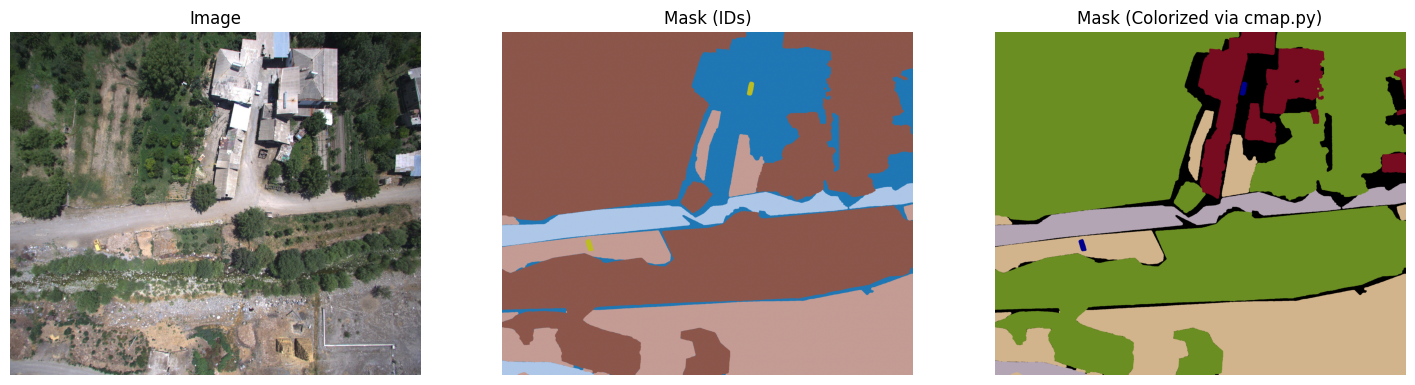

In [19]:
train_images = sorted(TRAIN_IMAGES_DIR.glob('*.jpg'))
if not train_images:
    train_images = sorted(TRAIN_IMAGES_DIR.glob('*.png'))
assert train_images, f'No prepared images found in {TRAIN_IMAGES_DIR}'

img_path = random.choice(train_images)
mask_path = TRAIN_MASKS_DIR / f'{img_path.stem}.png'
assert mask_path.exists(), f'Mask missing for {img_path.stem}: {mask_path}'

img = Image.open(img_path).convert('RGB')
mask_id = np.array(Image.open(mask_path), dtype=np.uint8)
mask_rgb = colorize_id_mask(mask_id)

present = sorted({int(x) for x in np.unique(mask_id)})
present_names = [(cid, CMAP[cid].get('name') or f'class_{cid}') for cid in present]

print('Example image:', img_path)
print('Example mask :', mask_path)
print('Unique class IDs in mask:', present)
print('Class names:', present_names)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(img)
ax[0].set_title('Image')
ax[0].axis('off')

ax[1].imshow(mask_id, cmap='tab20', vmin=0, vmax=NUM_CLASSES - 1)
ax[1].set_title('Mask (IDs)')
ax[1].axis('off')

ax[2].imshow(mask_rgb)
ax[2].set_title('Mask (Colorized via cmap.py)')
ax[2].axis('off')
plt.show()

## Step 11 — Define the PyTorch Dataset (fixed class mapping)

We **do not** use the repo's `BasicDataset` here because it scans masks and remaps labels.

For AMtown we want a **stable mapping**:
- model outputs are 26 channels (0..25)
- masks use IDs 0..25 directly

This dataset:
- loads images + masks by matching filename stems
- optionally rescales both image and mask (recommended for large images)
- returns:
  - `image`: float tensor `[C,H,W]` in range [0,1]
  - `mask`: long tensor `[H,W]` with values in `[0, 25]`

In [20]:
class AMtownFlatDataset(Dataset):
    def __init__(self, images_dir: Path, masks_dir: Path, scale: float = 1.0):
        self.images_dir = Path(images_dir)
        self.masks_dir = Path(masks_dir)
        assert 0 < scale <= 1.0
        self.scale = float(scale)

        # Build IDs from image files
        img_files = [p for p in self.images_dir.iterdir() if p.is_file() and not p.name.startswith('.')]
        img_files = [p for p in img_files if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.tif', '.tiff'}]
        self.ids = sorted([p.stem for p in img_files])
        if not self.ids:
            raise RuntimeError(f'No images found in {self.images_dir}')

        # Fast value→index mapping (identity for 0..25, but we still validate)
        self.valid_ids = np.arange(NUM_CLASSES, dtype=np.uint8)  # 0..25
        self.value_to_index = np.full((256,), 255, dtype=np.uint8)
        for v in self.valid_ids:
            self.value_to_index[int(v)] = int(v)

    def __len__(self):
        return len(self.ids)

    def _load_image(self, stem: str) -> Image.Image:
        # accept multiple extensions
        candidates = []
        for ext in ['.jpg', '.jpeg', '.png', '.tif', '.tiff']:
            p = self.images_dir / (stem + ext)
            if p.exists():
                candidates.append(p)
        if len(candidates) != 1:
            raise FileNotFoundError(f'Expected 1 image for {stem}, got {candidates}')
        return Image.open(candidates[0]).convert('RGB')

    def _load_mask(self, stem: str) -> Image.Image:
        p = self.masks_dir / (stem + '.png')
        if not p.exists():
            raise FileNotFoundError(f'Mask not found: {p}')
        # Keep as grayscale (IDs)
        return Image.open(p)

    def _resize(self, img: Image.Image, is_mask: bool) -> Image.Image:
        if self.scale == 1.0:
            return img
        w, h = img.size
        nw, nh = int(w * self.scale), int(h * self.scale)
        if nw <= 0 or nh <= 0:
            raise ValueError('Scale too small, resized size is zero')
        resample = Image.NEAREST if is_mask else Image.BICUBIC
        return img.resize((nw, nh), resample=resample)

    def __getitem__(self, idx: int):
        stem = self.ids[idx]

        img = self._load_image(stem)
        mask = self._load_mask(stem)

        if img.size != mask.size:
            raise ValueError(f'Size mismatch for {stem}: image={img.size}, mask={mask.size}')

        img = self._resize(img, is_mask=False)
        mask = self._resize(mask, is_mask=True)

        img_np = np.array(img, dtype=np.float32)  # HWC, 0..255
        img_np = img_np.transpose(2, 0, 1) / 255.0  # CHW, 0..1

        mask_np = np.array(mask, dtype=np.uint8)
        if mask_np.ndim != 2:
            raise ValueError(f'Expected 2D mask, got shape {mask_np.shape} for {stem}')

        mapped = self.value_to_index[mask_np]
        if (mapped == 255).any():
            bad = int(mask_np[mapped == 255][0])
            raise ValueError(f'Unknown class id {bad} in mask for {stem}')

        return {
            'image': torch.from_numpy(img_np).float().contiguous(),
            'mask': torch.from_numpy(mapped.astype(np.int64)).long().contiguous(),
            'stem': stem,
        }

print('Dataset class ready')

Dataset class ready


## Step 12 — Create DataLoaders (train/val/test)

Recommended settings for Drive-based datasets:
- `num_workers=0` (Drive + multiprocessing can be unstable)
- small `batch_size` if your GPU RAM is limited
- smaller `SCALE` (e.g. 0.25) for large images

In [21]:
# Training configuration (you can tune these)
SCALE = 0.15
BATCH_SIZE = 1
VAL_PERCENT = 0.1
NUM_WORKERS = 0
SEED = 0

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

full_train_ds = AMtownFlatDataset(TRAIN_IMAGES_DIR, TRAIN_MASKS_DIR, scale=SCALE)
n_val = int(len(full_train_ds) * VAL_PERCENT)
n_train = len(full_train_ds) - n_val
train_ds, val_ds = random_split(full_train_ds, [n_train, n_val], generator=torch.Generator().manual_seed(SEED))

test_ds = AMtownFlatDataset(TEST_IMAGES_DIR, TEST_MASKS_DIR, scale=SCALE)

loader_args = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
train_loader = DataLoader(train_ds, shuffle=True, **loader_args)
val_loader = DataLoader(val_ds, shuffle=False, drop_last=False, **loader_args)
test_loader = DataLoader(test_ds, shuffle=False, drop_last=False, **loader_args)

print('Train samples:', len(train_ds))
print('Val samples  :', len(val_ds))
print('Test samples :', len(test_ds))

Train samples: 3339
Val samples  : 370
Test samples : 1380


## Step 13 — Metrics helpers (Dice, IoU, Pixel Accuracy)

We compute evaluation metrics from a confusion matrix:
- per-class IoU
- mIoU (mean IoU over classes present in the test set)
- per-class Dice
- mean Dice
- pixel accuracy

We also report versions **with** and **without** background (class 0).

In [22]:
def update_confusion_matrix(conf: np.ndarray, pred: np.ndarray, target: np.ndarray, num_classes: int):
    mask = (target >= 0) & (target < num_classes)
    label = num_classes * target[mask].astype('int64') + pred[mask].astype('int64')
    count = np.bincount(label, minlength=num_classes ** 2)
    conf += count.reshape(num_classes, num_classes)

def metrics_from_confusion(conf: np.ndarray, ignore_background: bool = False) -> Dict:
    num_classes = conf.shape[0]
    diag = np.diag(conf).astype(np.float64)
    sum_row = conf.sum(axis=1).astype(np.float64)
    sum_col = conf.sum(axis=0).astype(np.float64)
    total = conf.sum().astype(np.float64)

    union = sum_row + sum_col - diag
    iou = diag / (union + 1e-10)
    dice = 2 * diag / (sum_row + sum_col + 1e-10)
    acc = diag / (sum_row + 1e-10)

    valid = sum_row > 0
    classes = np.arange(num_classes)

    if ignore_background:
        valid = valid & (classes != 0)

    miou = float(np.nanmean(iou[valid])) if valid.any() else float('nan')
    mdice = float(np.nanmean(dice[valid])) if valid.any() else float('nan')
    macc = float(np.nanmean(acc[valid])) if valid.any() else float('nan')
    pix_acc = float(diag.sum() / (total + 1e-10))

    return {
        'pixel_accuracy': pix_acc,
        'mean_iou': miou,
        'mean_dice': mdice,
        'mean_accuracy': macc,
        'per_class_iou': [float(x) for x in iou.tolist()],
        'per_class_dice': [float(x) for x in dice.tolist()],
        'per_class_accuracy': [float(x) for x in acc.tolist()],
        'valid_classes': [int(c) for c in classes[valid].tolist()],
    }

print('Metrics helpers ready')

Metrics helpers ready


## Step 14 — Training loop (U-Net)

This training loop is adapted from common U-Net training practice:
- optimizer: RMSprop
- loss: CrossEntropy + Dice loss
- mixed precision (AMP) if CUDA is available
- checkpoint saved after each epoch (to Drive)

You can safely interrupt and resume later by loading a checkpoint.

In [23]:
def compute_multiclass_dice(pred_logits: torch.Tensor, target: torch.Tensor, num_classes: int) -> float:
    """Dice score ignoring background (class 0), similar to the repo's evaluate.py."""
    probs = F.softmax(pred_logits, dim=1)
    pred_onehot = F.one_hot(probs.argmax(dim=1), num_classes).permute(0, 3, 1, 2).float()
    target_onehot = F.one_hot(target, num_classes).permute(0, 3, 1, 2).float()
    return float(1.0 - dice_loss(pred_onehot[:, 1:], target_onehot[:, 1:], multiclass=True))

@torch.inference_mode()
def validate(model: nn.Module, loader: DataLoader, device: torch.device, num_classes: int, use_amp: bool) -> Dict[str, float]:
    model.eval()
    dice_scores = []
    for batch in tqdm(loader, desc='Validating', leave=False):
        images = batch['image'].to(device=device, dtype=torch.float32)
        masks = batch['mask'].to(device=device, dtype=torch.long)
        with torch.amp.autocast('cuda', enabled=use_amp):
            logits = model(images)
        dice_scores.append(compute_multiclass_dice(logits, masks, num_classes))
    model.train()
    return {'val_dice_no_bg': float(np.mean(dice_scores)) if dice_scores else float('nan')}

def train_unet(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: torch.device,
    num_classes: int,
    epochs: int = 5,
    lr: float = 1e-4,
    weight_decay: float = 1e-8,
    momentum: float = 0.999,
    grad_clip: float = 1.0,
    use_amp: bool = True,
    checkpoint_dir: Path = Path('/content/drive/MyDrive/unet_amtown_checkpoints'),
) -> Dict[str, List[float]]:
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3)
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

    criterion = nn.CrossEntropyLoss()

    history = {
        'train_loss': [],
        'val_dice_no_bg': [],
        'lr': [],
    }

    global_step = 0
    for epoch in range(1, epochs + 1):
        model.train()
        epoch_losses = []

        pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}', unit='batch')
        for batch in pbar:
            images = batch['image'].to(device=device, dtype=torch.float32)
            masks = batch['mask'].to(device=device, dtype=torch.long)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda', enabled=use_amp):
                logits = model(images)
                ce = criterion(logits, masks)
                probs = F.softmax(logits, dim=1)
                masks_1h = F.one_hot(masks, num_classes).permute(0, 3, 1, 2).float()
                dloss = dice_loss(probs, masks_1h, multiclass=True)
                loss = ce + dloss

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()

            global_step += 1
            epoch_losses.append(float(loss.item()))
            pbar.set_postfix({'loss': float(loss.item())})

        # Validation
        val_metrics = validate(model, val_loader, device, num_classes, use_amp)
        val_dice = val_metrics['val_dice_no_bg']
        scheduler.step(val_dice)

        # Save checkpoint
        ckpt_path = checkpoint_dir / f'checkpoint_epoch{epoch}.pth'
        state = model.state_dict()
        state['mask_values'] = list(range(num_classes))
        torch.save(state, ckpt_path)

        history['train_loss'].append(float(np.mean(epoch_losses)))
        history['val_dice_no_bg'].append(val_dice)
        history['lr'].append(float(optimizer.param_groups[0]['lr']))

        print(f"Epoch {epoch}: train_loss={history['train_loss'][-1]:.4f} | val_dice(no_bg)={val_dice:.4f} | saved={ckpt_path}")

    return history

print('Training functions ready')

Training functions ready


## Step 15 — Run training

Tune these parameters based on your GPU:
- `SCALE`: smaller = less memory, faster
- `BATCH_SIZE`: smaller = less memory
- `EPOCHS`: more = better learning (usually)

Checkpoints are saved to Drive so you keep them even if the Colab session resets.

Epoch 1/12: 100%|██████████| 3339/3339 [11:21<00:00,  4.90batch/s, loss=0.328]


Epoch 1: train_loss=0.9948 | val_dice(no_bg)=0.8477 | saved=/content/drive/MyDrive/unet_amtown_checkpoints/checkpoint_epoch1.pth


Epoch 2/12: 100%|██████████| 3339/3339 [11:04<00:00,  5.03batch/s, loss=0.251]


Epoch 2: train_loss=0.3485 | val_dice(no_bg)=0.8807 | saved=/content/drive/MyDrive/unet_amtown_checkpoints/checkpoint_epoch2.pth


Epoch 3/12: 100%|██████████| 3339/3339 [10:56<00:00,  5.09batch/s, loss=0.167]


...

Epoch 10: train_loss=0.0786 | val_dice(no_bg)=0.9098 | saved=/content/drive/MyDrive/unet_amtown_checkpoints/checkpoint_epoch10.pth


Epoch 11/12: 100%|██████████| 3339/3339 [10:40<00:00,  5.21batch/s, loss=0.119]


Epoch 11: train_loss=0.0734 | val_dice(no_bg)=0.9192 | saved=/content/drive/MyDrive/unet_amtown_checkpoints/checkpoint_epoch11.pth


Epoch 12/12: 100%|██████████| 3339/3339 [10:46<00:00,  5.17batch/s, loss=0.0719]


Epoch 12: train_loss=0.0694 | val_dice(no_bg)=0.9165 | saved=/content/drive/MyDrive/unet_amtown_checkpoints/checkpoint_epoch12.pth


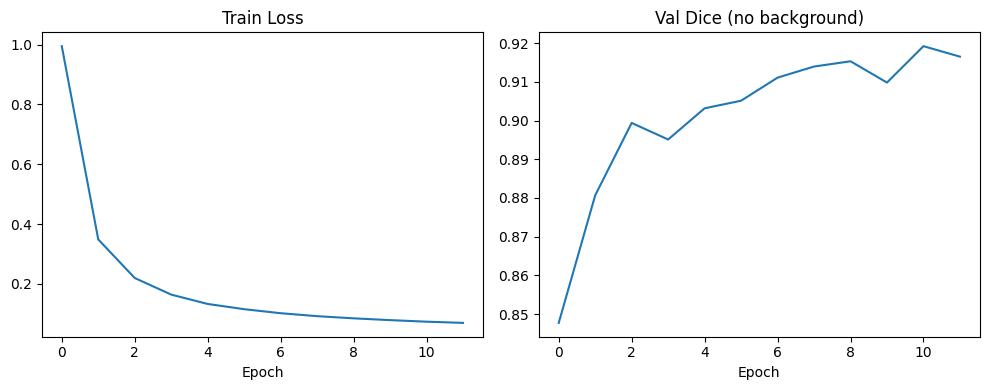

In [24]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = torch.cuda.is_available()

EPOCHS = 12
LR = 1e-4
CHECKPOINT_DIR = Path('/content/drive/MyDrive/unet_amtown_checkpoints')

model = UNet(n_channels=3, n_classes=NUM_CLASSES, bilinear=False).to(DEVICE)

history = train_unet(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=DEVICE,
    num_classes=NUM_CLASSES,
    epochs=EPOCHS,
    lr=LR,
    use_amp=USE_AMP,
    checkpoint_dir=CHECKPOINT_DIR,
)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history['train_loss'])
plt.title('Train Loss')
plt.xlabel('Epoch')

plt.subplot(1,2,2)
plt.plot(history['val_dice_no_bg'])
plt.title('Val Dice (no background)')
plt.xlabel('Epoch')
plt.tight_layout()
plt.show()

In [25]:
import pandas as pd
pd.DataFrame(history).to_csv('training_history.csv')

## Step 16 — Load a checkpoint for testing

We pick the latest checkpoint by default.
You can also set `MODEL_PATH` manually to test a specific epoch.

In [26]:
import re

ckpts = list(CHECKPOINT_DIR.glob('checkpoint_epoch*.pth'))
assert ckpts, f'No checkpoints found in {CHECKPOINT_DIR}'

def epoch_num(p: Path) -> int:
    m = re.search(r'checkpoint_epoch(\d+)\.pth', p.name)
    return int(m.group(1)) if m else -1

ckpts = sorted(ckpts, key=epoch_num)
MODEL_PATH = ckpts[-1]
print('Using checkpoint:', MODEL_PATH)

# Load model
state = torch.load(MODEL_PATH, map_location=DEVICE)
mask_values = state.pop('mask_values', list(range(NUM_CLASSES)))
assert mask_values == list(range(NUM_CLASSES)), 'Unexpected mask_values mapping'

model = UNet(n_channels=3, n_classes=NUM_CLASSES, bilinear=False).to(DEVICE)
model.load_state_dict(state)
model.eval();
print('Model loaded')

Using checkpoint: /content/drive/MyDrive/unet_amtown_checkpoints/checkpoint_epoch12.pth
Model loaded


## Step 17 — Test + Evaluate on AMtown02

We run inference on the test set and compute metrics.

To speed up a quick check, set `MAX_TEST_IMAGES` to a small number (e.g., 50).
For a full evaluation, set it to `None`.

In [27]:
@torch.inference_mode()
def evaluate_on_loader(model: nn.Module, loader: DataLoader, device: torch.device, num_classes: int, use_amp: bool, max_images=None) -> Dict:
    conf = np.zeros((num_classes, num_classes), dtype=np.int64)

    seen = 0
    for batch in tqdm(loader, desc='Testing', unit='img'):
        images = batch['image'].to(device=device, dtype=torch.float32)
        targets = batch['mask'].numpy()  # (B,H,W)

        with torch.amp.autocast('cuda', enabled=use_amp):
            logits = model(images)
        preds = logits.argmax(dim=1).cpu().numpy()  # (B,H,W)

        for p, t in zip(preds, targets):
            update_confusion_matrix(conf, p, t, num_classes)
            seen += 1
            if max_images is not None and seen >= max_images:
                break
        if max_images is not None and seen >= max_images:
            break

    metrics_all = metrics_from_confusion(conf, ignore_background=False)
    metrics_no_bg = metrics_from_confusion(conf, ignore_background=True)

    return {
        'num_classes': num_classes,
        'images_evaluated': int(seen),
        'metrics_all': metrics_all,
        'metrics_no_bg': metrics_no_bg,
        'confusion_matrix': conf,
    }

MAX_TEST_IMAGES = None  # set e.g. 100 for a fast check
test_report = evaluate_on_loader(model, test_loader, DEVICE, NUM_CLASSES, USE_AMP, max_images=MAX_TEST_IMAGES)

print('\nTest metrics (ALL classes)')
print('  pixel_accuracy:', test_report['metrics_all']['pixel_accuracy'])
print('  mean_iou      :', test_report['metrics_all']['mean_iou'])
print('  mean_dice     :', test_report['metrics_all']['mean_dice'])

print('\nTest metrics (IGNORE background class 0)')
print('  pixel_accuracy:', test_report['metrics_no_bg']['pixel_accuracy'])
print('  mean_iou      :', test_report['metrics_no_bg']['mean_iou'])
print('  mean_dice     :', test_report['metrics_no_bg']['mean_dice'])

Testing: 100%|██████████| 1380/1380 [03:37<00:00,  6.35img/s]


Test metrics (ALL classes)
  pixel_accuracy: 0.9310350981925896
  mean_iou      : 0.6194424450072537
  mean_dice     : 0.7401386073151246

Test metrics (IGNORE background class 0)
  pixel_accuracy: 0.9310350981925896
  mean_iou      : 0.6092681327585499
  mean_dice     : 0.7312305988372003


## Step 18 — Per-class results table (IoU/Dice)

We show per-class IoU and Dice for classes that appear in the test set.
Class names come from `cmap.py`.

In [28]:
valid = set(test_report['metrics_all']['valid_classes'])
iou = test_report['metrics_all']['per_class_iou']
dice = test_report['metrics_all']['per_class_dice']

print('{:<4} {:<24} {:>10} {:>10}'.format('ID', 'Name', 'IoU', 'Dice'))
print('-' * 52)
for cid in range(NUM_CLASSES):
    if cid not in valid:
        continue
    name = CMAP.get(cid, {}).get('name') or f'class_{cid}'
    print('{:<4} {:<24} {:>10.4f} {:>10.4f}'.format(cid, name, float(iou[cid]), float(dice[cid])))

ID   Name                            IoU       Dice
----------------------------------------------------
0    background                   0.7619     0.8649
1    roof                         0.8749     0.9333
2    dirt_motor_road              0.7661     0.8676
3    paved_motor_road             0.5390     0.7005
5    pool                         0.3920     0.5632
6    bridge                       0.7398     0.8504
13   green_field                  0.9445     0.9715
14   wild_field                   0.6533     0.7903
15   solar_board                  0.7895     0.8824
16   umbrella                     0.2560     0.4076
17   transparent_roof             0.8657     0.9280
19   paved_walk                   0.5946     0.7457
20   sedan                        0.4414     0.6124
24   truck                        0.4528     0.6233
25   class_25                     0.2203     0.3611


## Step 19 — Save evaluation report to Drive

This saves a JSON file with metrics so you can keep results.

In [29]:
REPORT_PATH = CHECKPOINT_DIR / 'amtown02_evaluation_report.json'

serializable = dict(test_report)
serializable['confusion_matrix'] = serializable['confusion_matrix'].tolist()
serializable['model_path'] = str(MODEL_PATH)
serializable['scale'] = SCALE
serializable['train_splits'] = TRAIN_SPLITS
serializable['test_splits'] = TEST_SPLITS

with open(REPORT_PATH, 'w') as f:
    json.dump(serializable, f, indent=2)

print('Saved report to:', REPORT_PATH)

Saved report to: /content/drive/MyDrive/unet_amtown_checkpoints/amtown02_evaluation_report.json


## Step 20 — Qualitative results (visualize predictions)

We randomly sample a few test images and visualize:
- input image
- ground-truth mask (colorized)
- predicted mask (colorized)

This is useful to judge segmentation quality visually.

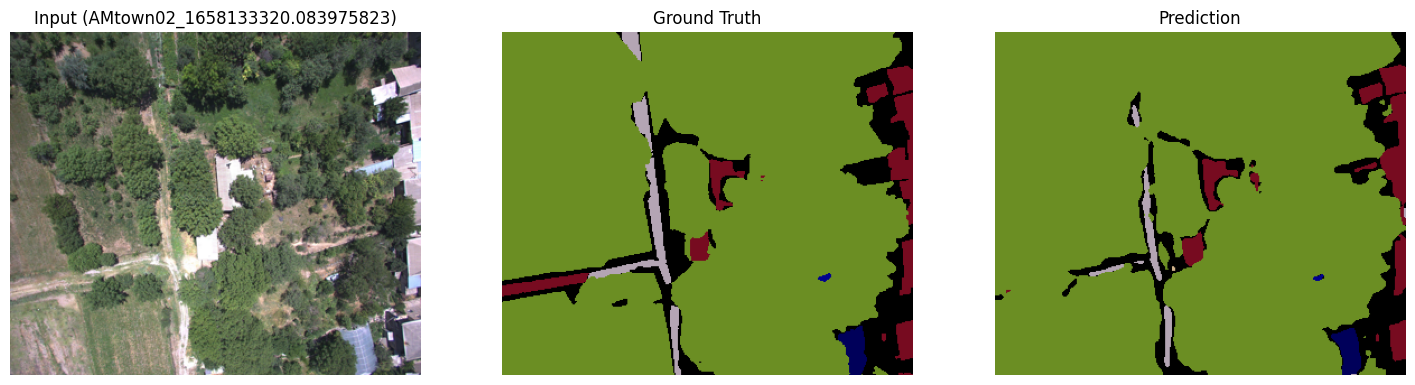

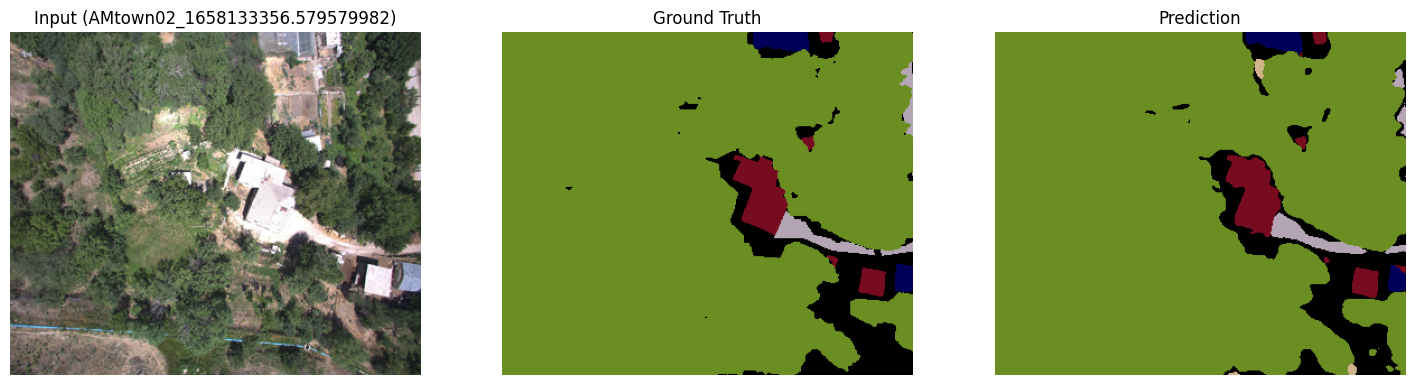

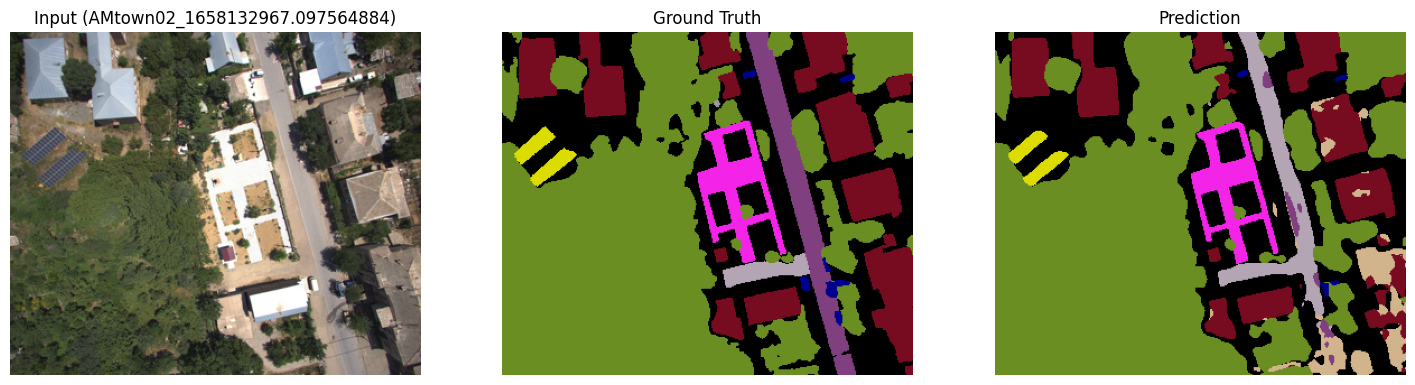

In [30]:
@torch.inference_mode()
def visualize_predictions(model: nn.Module, dataset: Dataset, device: torch.device, n: int = 3):
    indices = random.sample(range(len(dataset)), k=min(n, len(dataset)))
    for idx in indices:
        sample = dataset[idx]
        img = sample['image'].unsqueeze(0).to(device=device, dtype=torch.float32)
        gt = sample['mask'].numpy().astype(np.uint8)

        logits = model(img)
        pred = logits.argmax(dim=1)[0].cpu().numpy().astype(np.uint8)

        img_vis = (sample['image'].numpy().transpose(1, 2, 0) * 255).astype(np.uint8)
        gt_rgb = colorize_id_mask(gt)
        pred_rgb = colorize_id_mask(pred)

        fig, ax = plt.subplots(1, 3, figsize=(18, 6))
        ax[0].imshow(img_vis)
        ax[0].set_title(f'Input ({sample["stem"]})')
        ax[0].axis('off')

        ax[1].imshow(gt_rgb)
        ax[1].set_title('Ground Truth')
        ax[1].axis('off')

        ax[2].imshow(pred_rgb)
        ax[2].set_title('Prediction')
        ax[2].axis('off')
        plt.show()

visualize_predictions(model, test_ds, DEVICE, n=3)

## Troubleshooting

- **Labels missing**: you must upload `AMtown_label/...` to Drive (either `_label_id` or `_label_color`).
- **`Unknown label color ...`**: your color masks contain RGB values not listed in `cmap.py`.
- **Size mismatch**: each mask must have the exact same width/height as the corresponding image.
- **CUDA OOM**: reduce `BATCH_SIZE`, reduce `SCALE` (try 0.25), use GPU + AMP.
- **Drive is slow**: set `PREP_MODE='copy'` to copy prepared data into `/content` (needs disk space).